## EDA Notebook

Readmission risk can be understood across four dimensions: who the patient is biologically, how complex their condition is, how severe this specific admission was, and what their history of care looks like. The EDA is organized around these dimensions rather than individual features, using clinical reasoning to guide which columns are worth investigating and why.

The first examines glycemic control through HbA1c results, investigating whether poor long-term glucose management correlates with higher readmission rates. Given the high missingness in this column, the analysis also explores whether the absence of an A1C test itself carries signal.

The second investigates clinical severity through primary and secondary diagnoses. Does having more than one diagnosis increase readmission risk? Do diagnoses with known high comorbidity rates with diabetes, such as cardiac and renal conditions, show stronger associations than unrelated diagnoses?

The third thread examines treatment complexity. Do medication changes during the admission indicate better or worse outcomes? Are patients not on any diabetes medications at higher readmission risk, suggesting unmanaged disease?

The fourth looks at admission burden: time in hospital, number of procedures, and number of medications. I hypothesize that time in hospital will show a non-linear relationship with readmission, as very short stays may indicate premature discharge and very long stays may reflect severity or in-hospital mortality, both distorting the readmission signal in opposite directions.

The fifth examines prior utilization history. Does a patient's record of inpatient, outpatient, and emergency visits in the prior year predict future readmission? The hypothesis is that prior hospitalization frequency is one of the strongest available proxies for disease severity and care management failure.

### Note:
This analysis includes all encounters prior to deduplication. Patients with multiple admissions may influence readmission rates in some categories. These findings will be validated against the deduplicated dataset during feature engineering.


In [143]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../diabetes-readmission.db')

df = pd.read_sql("""
    SELECT * FROM encounters
""",conn)

conn.close()
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [144]:
df['readmitted-binary'] = (df['readmitted'] != 'NO').astype(int)

print(df['readmitted-binary'].value_counts())
print(df['readmitted-binary'].value_counts(normalize=True))

readmitted-binary
0    54864
1    46902
Name: count, dtype: int64
readmitted-binary
0    0.539119
1    0.460881
Name: proportion, dtype: float64


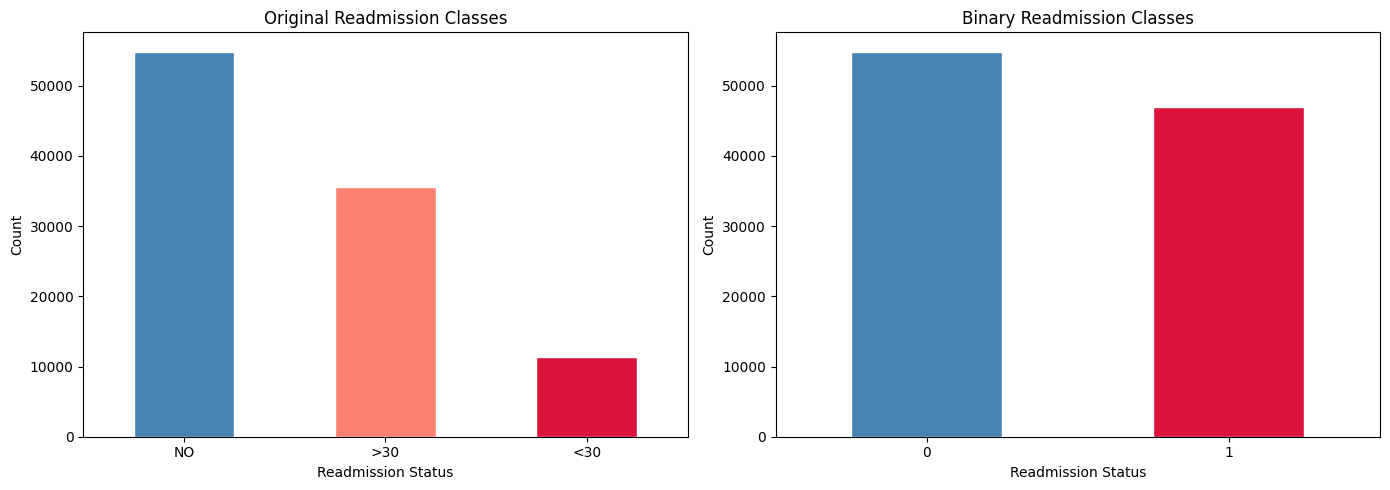

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon', 'crimson'], edgecolor='white'
)
axes[0].set_title('Original Readmission Classes')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['readmitted-binary'].value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'crimson'], edgecolor='white'
)
axes[1].set_title('Binary Readmission Classes')
axes[1].set_xlabel('Readmission Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Note:

Nearly 46% of diabetic patients in this dataset were readmitted after discharge, suggesting that readmission is not a rare edge case but a systemic failure affecting nearly half of all diabetic hospital patients. This framing shifts the problem from anomaly detection to risk stratification; the goal is not to find rare outliers but to distinguish between two comparably sized populations with meaningfully different clinical profiles.

## A1C Results

The first thread examined long-term glucose management through HbA1c results and its correlation with readmission rates. While A1C result shows a directional relationship with readmission risk, the spread across categories is narrow, making it a weak standalone signal. Notably, the Unknown category has the highest readmission rate of all groups, suggesting that the absence of an A1C test may itself be a confounding signal for admission severity rather than simply missing data. The feature will be retained and its predictive value assessed during modeling.

In [146]:
import numpy as np

df['A1Cresult'] = df['A1Cresult'].fillna("UNK")
df['A1Cresult'].value_counts(normalize=True)

A1Cresult
UNK     0.832773
>8      0.080734
Norm    0.049034
>7      0.037458
Name: proportion, dtype: float64

In [147]:
result = pd.crosstab(df['A1Cresult'], df['readmitted-binary'])

result['readmission-ratio'] = result[1].values / (result[0].values + result[1].values)
result['non-readmission-ratio'] = result[0].values / (result[0].values + result[1].values)

result

readmitted-binary,0,1,readmission-ratio,non-readmission-ratio
A1Cresult,,,,
>7,2129,1683,0.441501,0.558499
>8,4504,3712,0.451801,0.548199
Norm,2909,2081,0.417034,0.582966
UNK,45322,39426,0.465215,0.534785


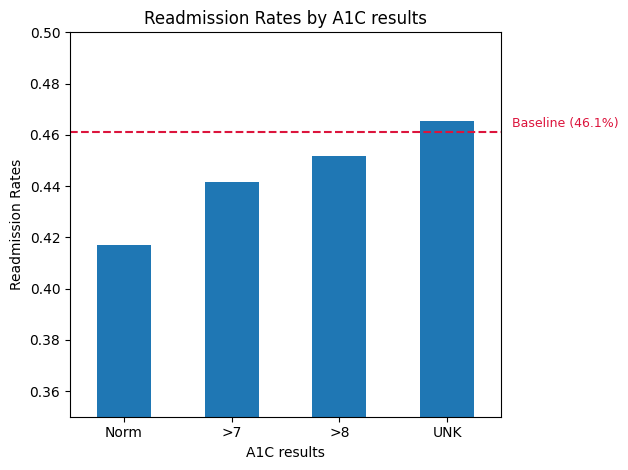

In [148]:
order = ['Norm', '>7', '>8', 'UNK']
result.loc[order, 'readmission-ratio'].plot(
    kind='bar',
    title='Readmission Rates by A1C results',
    xlabel='A1C results',
    ylabel='Readmission Rates',
    rot=0,
    ylim=(0.35, 0.50)
)

plt.axhline(y=0.461, color='crimson', linestyle='--', linewidth=1.5, label='Baseline (46.1%)')
plt.text(3.6, 0.463, 'Baseline (46.1%)', color='crimson', fontsize=9)
plt.tight_layout()
plt.show()

## Diagnosis Features

The diagnosis analysis examined whether specific primary or secondary diagnoses, individually or in combination, predicted higher readmission rates.

For individual diagnoses, blood disease and diabetes as primary diagnoses showed the highest readmission rates, both exceeding the 46.1% baseline. Notably, diabetes as a secondary diagnosis showed below-average readmission rates, suggesting patients admitted primarily for other conditions have better baseline diabetes management than those admitted for a diabetic crisis. Skin conditions emerging as a high-risk secondary diagnosis was unexpected, and further investigation revealed this was largely driven by diabetic wound and ulcer complications in patients whose primary diagnosis was diabetes.

The comorbidity heatmap identified five high-risk diagnosis pairings, each deviating at least 18 percentage points above baseline, meaning these patients were approximately 39% more likely to be readmitted. The highest-risk reliable combination was Supplementary/Neoplasms at 71%, representing cancer patients admitted for follow-up care. Diabetes/Diabetes at 64% identified patients with multi-faceted diabetic disease as a critical high-risk subgroup. Ill-defined Conditions/External at 64% likely reflects patients whose root cause was never identified during admission, making discharge a temporary measure rather than a resolution.

In [149]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    v_codes = df[col].str.startswith('V', na=False).sum()
    e_codes = df[col].str.startswith('E', na=False).sum()
    print(f"{col}: {v_codes} V-codes, {e_codes} E-codes")

diag_1: 1644 V-codes, 1 E-codes
diag_2: 1805 V-codes, 731 E-codes
diag_3: 3814 V-codes, 1244 E-codes


In [150]:
def categorize_icd9(code):
    code = str(code).strip()
    
    if code == '?':
        return "Unknown"
    
    if code.startswith('V'):
        return "Supplementary"
    if code.startswith("E"):
        return "External"
    
    try:
        num = float(code)
    except ValueError:
        return "Other"
    
    if num < 140:
        return "Infectious Disease"
    elif num >=140 and num < 240:
        return "Neoplasms"
    elif num >=240 and num < 280:
        if num >= 250 and num < 251:
            return "Diabetes"
        return "Endocrine"
    elif num >=280 and num < 290:
        return "Blood Disease"
    elif num >=290 and num < 320:
        return "Behavioral"
    elif num >=320 and num < 390:
        return "Nervous System"
    elif num >=390 and num < 460:
        return "Circulatory"
    elif num >=460 and num < 520:
        return "Respiratory"
    elif num >=520 and num < 580:
        return "Digestive"
    elif num >=580 and num < 630:
        return "Genitourinary"
    elif num >=630 and num < 680:
        return "Pregnancy"
    elif num >=680 and num < 710:
        return "Skin"
    elif num >=710 and num < 740:
        return "Musculoskeletal"
    elif num >=740 and num < 760:
        return "Congenital Anomalies"
    elif num >=760 and num < 780:
        return "Perinatal"
    elif num >=780 and num < 800:
        return "Ill-defined Conditions"
    elif num >=800 and num < 1000:
        return "Injury and Poisoning"
    
    

    return "Other"


In [151]:
df['diag_1_cat'] = df['diag_1'].apply(categorize_icd9)
df['diag_2_cat'] = df['diag_2'].apply(categorize_icd9)
df['diag_3_cat'] = df['diag_3'].apply(categorize_icd9)

print(df['diag_1_cat'].value_counts())

diag_1_cat
Circulatory               30336
Respiratory               10407
Digestive                  9208
Diabetes                   8757
Ill-defined Conditions     7636
Injury and Poisoning       6974
Genitourinary              5078
Musculoskeletal            4957
Neoplasms                  3433
Infectious Disease         2768
Endocrine                  2702
Skin                       2530
Behavioral                 2262
Supplementary              1644
Nervous System             1211
Blood Disease              1103
Pregnancy                   687
Congenital Anomalies         51
Unknown                      21
External                      1
Name: count, dtype: int64


In [152]:
print(df['diag_2_cat'].value_counts())

diag_2_cat
Circulatory               31365
Diabetes                  12794
Respiratory               10251
Endocrine                  8223
Genitourinary              7987
Ill-defined Conditions     4632
Digestive                  3962
Skin                       3596
Blood Disease              2926
Behavioral                 2657
Neoplasms                  2547
Injury and Poisoning       2428
Infectious Disease         1931
Supplementary              1805
Musculoskeletal            1764
Nervous System             1286
External                    731
Pregnancy                   415
Unknown                     358
Congenital Anomalies        108
Name: count, dtype: int64


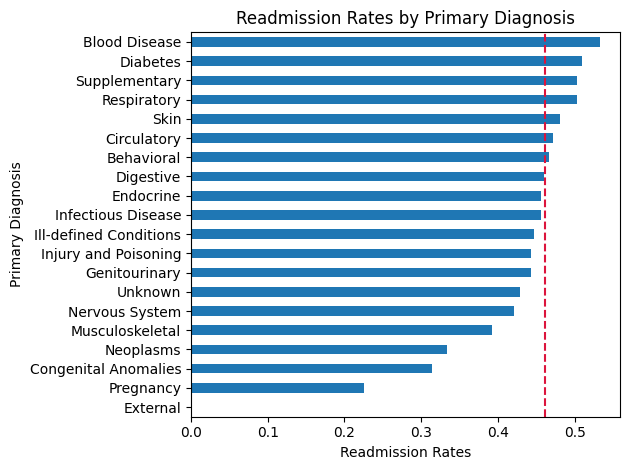

In [153]:
diag1_rates = df.groupby('diag_1_cat')['readmitted-binary'].mean().sort_values(ascending=True)

diag1_rates.plot(
    kind='barh',
    title='Readmission Rates by Primary Diagnosis',
    ylabel='Primary Diagnosis',
    xlabel='Readmission Rates',
    rot=0
)

plt.axvline(x=0.461, color='crimson', linestyle='--', linewidth=1.5, label='Baseline (46.1%)')
plt.tight_layout()
plt.show()

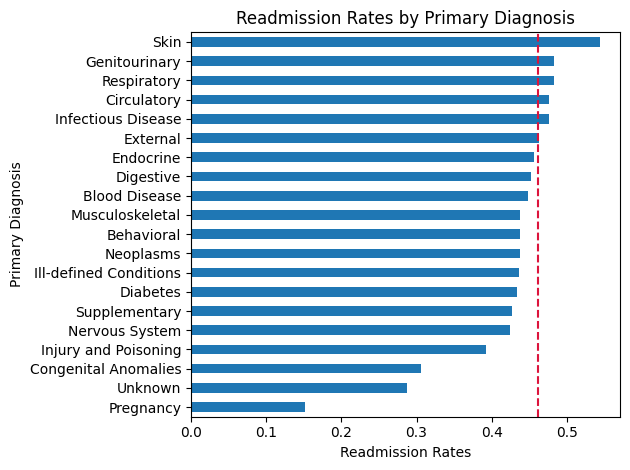

In [154]:
diag2_rates = df.groupby('diag_2_cat')['readmitted-binary'].mean().sort_values(ascending=True)

diag2_rates.plot(
    kind='barh',
    title='Readmission Rates by Primary Diagnosis',
    ylabel='Primary Diagnosis',
    xlabel='Readmission Rates',
    rot=0
)

plt.axvline(x=0.461, color='crimson', linestyle='--', linewidth=1.5, label='Baseline (46.1%)')
plt.tight_layout()
plt.show()

In [155]:
baseline = df['readmitted-binary'].mean()

above_avg_primary = diag1_rates[diag1_rates > baseline].index.tolist()
above_avg_secondary = diag2_rates[diag2_rates > baseline].index.tolist()

print("Above average primary:", above_avg_primary)
print("Above average secondary:", above_avg_secondary)

above_avg = set(above_avg_primary + above_avg_secondary)
print(above_avg)

Above average primary: ['Behavioral', 'Circulatory', 'Skin', 'Respiratory', 'Supplementary', 'Diabetes', 'Blood Disease']
Above average secondary: ['External', 'Infectious Disease', 'Circulatory', 'Respiratory', 'Genitourinary', 'Skin']
{'Diabetes', 'Skin', 'Circulatory', 'Genitourinary', 'Supplementary', 'Respiratory', 'External', 'Blood Disease', 'Infectious Disease', 'Behavioral'}


In [156]:
mask = (df['diag_1_cat'].isin(above_avg)) | (df['diag_2_cat'].isin(above_avg))
print(mask)
df_filtered = df[mask]

combo_rates = pd.crosstab(
    df_filtered['diag_1_cat'],
    df_filtered['diag_2_cat'],
    values = df_filtered['readmitted-binary'],
    aggfunc='mean'
)

print(combo_rates.shape)
print(combo_rates)

0          True
1          True
2          True
3          True
4         False
          ...  
101761     True
101762    False
101763     True
101764     True
101765    False
Length: 101766, dtype: bool
(20, 20)
diag_2_cat              Behavioral  Blood Disease  Circulatory  \
diag_1_cat                                                       
Behavioral                0.438168       0.470588     0.485623   
Blood Disease             0.521739       0.553571     0.571429   
Circulatory               0.412698       0.496144     0.464279   
Congenital Anomalies           NaN       0.000000     0.294118   
Diabetes                  0.514793       0.520548     0.552870   
Digestive                 0.509881       0.491289     0.462275   
Endocrine                 0.458333       0.457143     0.509464   
External                       NaN            NaN     0.000000   
Genitourinary             0.421875       0.339450     0.506289   
Ill-defined Conditions    0.351064       0.456897     0.46618

In [157]:
combo_counts = pd.crosstab(
    df_filtered['diag_1_cat'],
    df_filtered['diag_2_cat']
)

combo_rates_masked = combo_rates.copy()
combo_rates_masked[combo_counts < 30] = np.nan

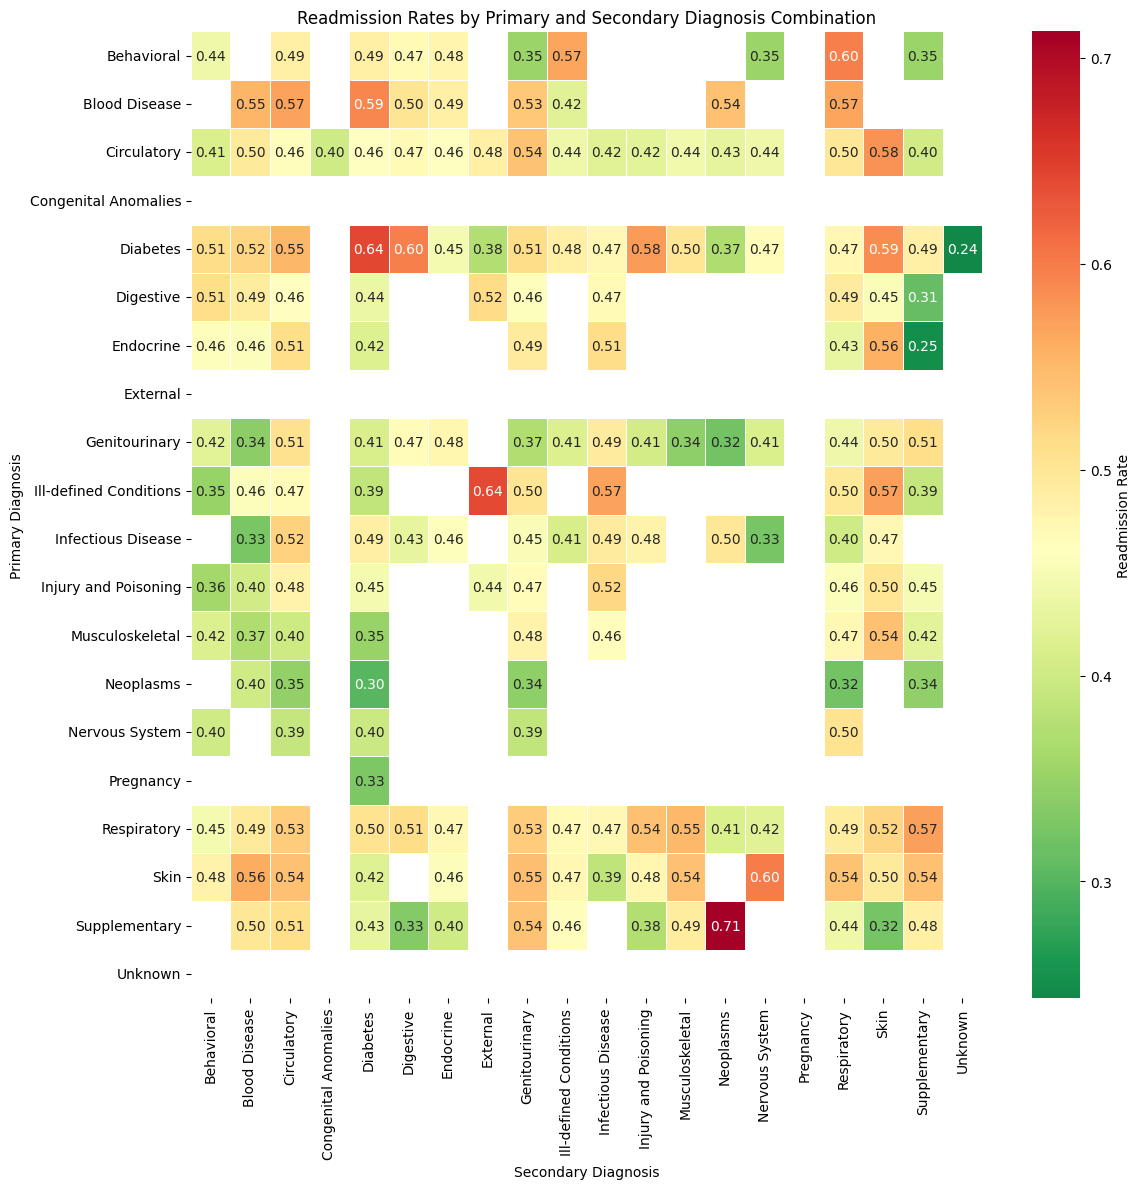

In [158]:
import seaborn as sns

plt.figure(figsize=(12,12))
sns.heatmap(
    combo_rates_masked,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=baseline,
    linewidths=0.5,
    cbar_kws={'label': 'Readmission Rate'}
)

plt.title('Readmission Rates by Primary and Secondary Diagnosis Combination')
plt.xlabel('Secondary Diagnosis')
plt.ylabel('Primary Diagnosis')
plt.tight_layout()
plt.show()